# Customer Churn & Retention Analysis

## 📊 Project Overview

This project analyzes customer churn patterns in a telecommunications dataset to understand which customer characteristics, services, pricing factors, and contract types are associated with higher observed churn.

The analysis uses **Python, Pandas, Matplotlib, SQL, and Power BI** to transform raw customer data into business insights.

### Objectives

* Understand the overall customer churn rate
* Identify customer segments with higher observed churn
* Analyze churn across contract and payment types
* Explore the relationship between tenure and churn
* Examine service and pricing-related churn patterns
* Generate actionable insights for customer retention analysis

### Dataset

The dataset contains **7,043 customer records** with demographic, service, account, contract, billing, and churn information.

### Tools Used

* Python
* Pandas
* Matplotlib
* MySQL
* Power BI

> **Note:** The analysis identifies observed relationships in the dataset and does not establish causal relationships.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned dataset
file_path = "../data/cleaned/telco_customer_churn_cleaned.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7043, 22)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


## 🔍 Dataset Inspection

Before performing the analysis, the dataset was inspected for:

* Number of rows and columns
* Data types
* Missing values
* Duplicate records
* Unique values in important categorical columns

In [2]:
# Dataset dimensions
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Data types
print("\nData types:")
display(df.dtypes)

# Missing values
print("\nMissing values:")
display(df.isnull().sum())

# Duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

Rows: 7043
Columns: 22

Data types:


customerID           object
gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
ChurnFlag             int64
dtype: object


Missing values:


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
ChurnFlag           0
dtype: int64


Duplicate rows: 0


## 🧹 Data Cleaning & Feature Engineering

The cleaned dataset was prepared before analysis by:

* Converting `TotalCharges` from text to numeric format
* Handling blank `TotalCharges` values for zero-tenure customers
* Converting `SeniorCitizen` from `0/1` into categorical `No/Yes` values
* Creating a numerical `ChurnFlag` for analysis
* Verifying and removing duplicate records
* Creating customer tenure groups
* Creating monthly charge groups

In [4]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing TotalCharges for zero-tenure customers
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Convert SeniorCitizen to categorical labels
df["SeniorCitizen"] = df["SeniorCitizen"].replace({
    0: "No",
    1: "Yes"
})

# Create churn flag
df["ChurnFlag"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# Create tenure groups
df["Tenure Group"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"]
)

# Create monthly charge groups
df["Monthly Charge Group"] = pd.cut(
    df["MonthlyCharges"],
    bins=[-1, 35, 70, 100, float("inf")],
    labels=["Under $35", "$35-$69", "$70-$99", "$100+"]
)

print("Missing values after cleaning:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values after cleaning: 0
Duplicate rows: 0


## 📊 Overall Customer Churn

The first analysis looks at the overall distribution of churned and retained customers.

This provides a baseline churn rate before investigating individual customer characteristics and services.

In [5]:
# Overall churn counts and rate

churn_counts = df["Churn"].value_counts()

churn_rate = df["ChurnFlag"].mean() * 100

print("Total Customers:", len(df))
print("Churned Customers:", churn_counts["Yes"])
print("Retained Customers:", churn_counts["No"])
print(f"Overall Churn Rate: {churn_rate:.2f}%")

Total Customers: 7043
Churned Customers: 1869
Retained Customers: 5174
Overall Churn Rate: 26.54%


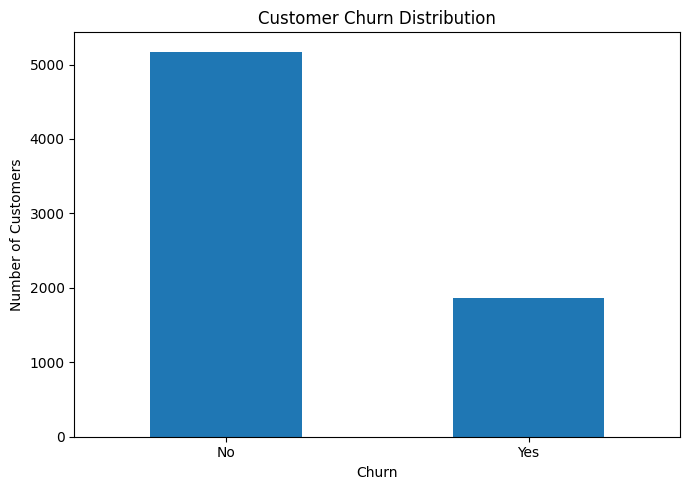

In [6]:
# Churn distribution

churn_counts.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 📄 Churn by Contract Type

Contract duration shows a strong difference in observed churn rates.

Month-to-month customers have a substantially higher observed churn rate than customers on one-year or two-year contracts.

In [8]:
# Churn rate by contract type

contract_churn = (
    df.groupby("Contract")["ChurnFlag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

display(contract_churn)

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: ChurnFlag, dtype: float64

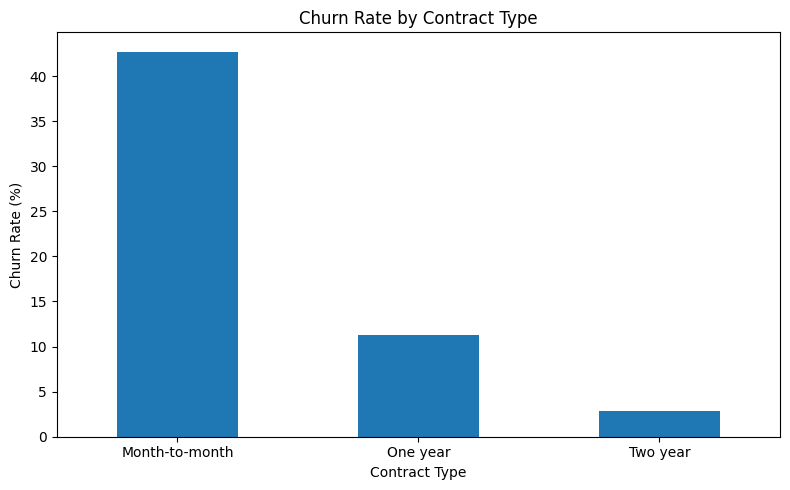

In [9]:
# Visualize churn rate by contract

contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## ⏳ Churn by Customer Tenure

Customer tenure is strongly associated with observed churn in this dataset.

Customers in the earliest tenure group show a substantially higher churn rate than longer-tenured customers.

In [10]:
# Churn rate by tenure group

tenure_churn = (
    df.groupby("Tenure Group", observed=True)["ChurnFlag"]
    .mean()
    .mul(100)
)

display(tenure_churn)

Tenure Group
0-12 months     47.438243
13-24 months    28.710938
25-48 months    20.388959
49-72 months     9.513176
Name: ChurnFlag, dtype: float64

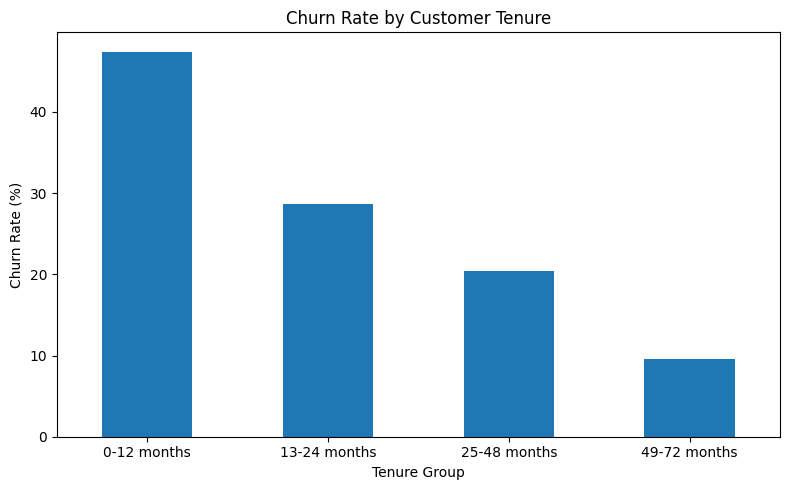

In [11]:
# Visualize churn rate by tenure

tenure_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 💳 Churn by Payment Method

Churn rates vary considerably across payment methods.

Customers using electronic checks show a higher observed churn rate than customers using automatic bank transfers, credit cards, or mailed checks.

In [12]:
# Churn rate by payment method

payment_churn = (
    df.groupby("PaymentMethod")["ChurnFlag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

display(payment_churn)

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: ChurnFlag, dtype: float64

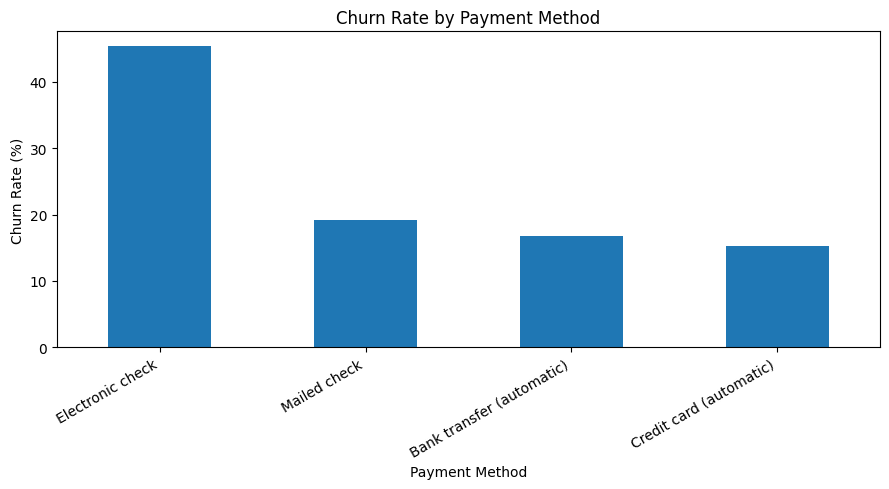

In [13]:
# Visualize churn rate by payment method

payment_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 🌐 Churn by Internet Service

Observed churn rates differ across internet service types.

Fiber optic customers show a higher observed churn rate than DSL customers and customers without internet service.

In [14]:
# Churn rate by internet service

internet_churn = (
    df.groupby("InternetService")["ChurnFlag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

display(internet_churn)

InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: ChurnFlag, dtype: float64

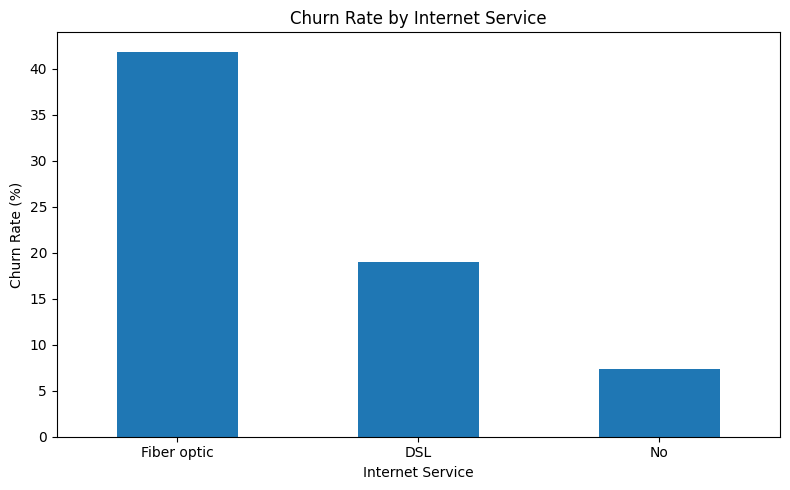

In [15]:
# Visualize churn rate by internet service

internet_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 💰 Churn by Monthly Charges

Customers with higher monthly charges show higher observed churn in this dataset.

This analysis groups customers into monthly charge ranges to identify differences in churn rates across pricing segments.

In [16]:
# Churn rate by monthly charge group

charge_churn = (
    df.groupby("Monthly Charge Group", observed=True)["ChurnFlag"]
    .mean()
    .mul(100)
)

display(charge_churn)

Monthly Charge Group
Under $35    10.893372
$35-$69      23.942029
$70-$99      37.821708
$100+        28.048780
Name: ChurnFlag, dtype: float64

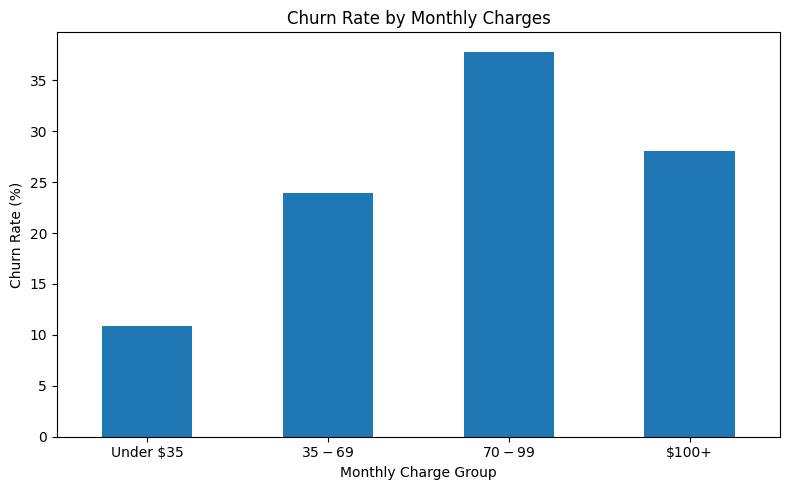

In [17]:
# Visualize churn rate by monthly charge group

charge_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Monthly Charges")
plt.xlabel("Monthly Charge Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 🛠️ Churn by Technical Support

Customers' use of technical support services shows differences in observed churn rates.

Customers without technical support have a higher observed churn rate than customers who have technical support.

In [18]:
# Churn rate by technical support

tech_support_churn = (
    df.groupby("TechSupport")["ChurnFlag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

display(tech_support_churn)

TechSupport
No                     41.635474
Yes                    15.166341
No internet service     7.404980
Name: ChurnFlag, dtype: float64

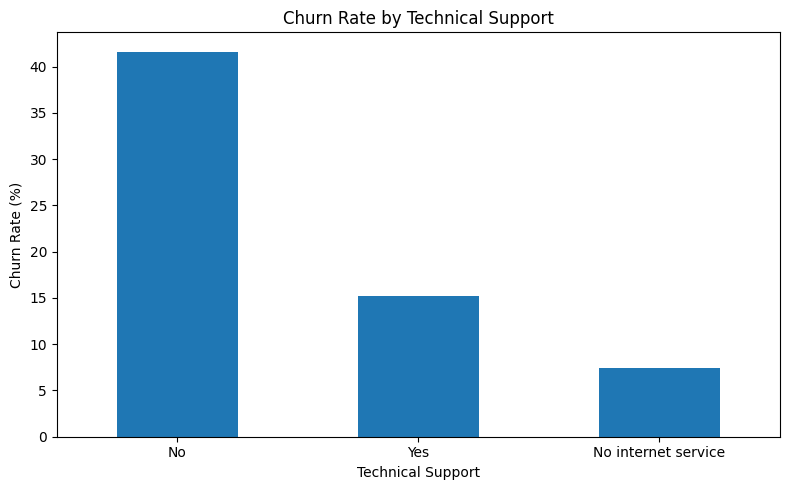

In [19]:
# Visualize churn rate by technical support

tech_support_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Technical Support")
plt.xlabel("Technical Support")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 🔐 Churn by Online Security

Customers' use of online security services shows differences in observed churn rates.

Customers without online security have a higher observed churn rate than customers who have the service.

In [20]:
# Churn rate by online security

security_churn = (
    df.groupby("OnlineSecurity")["ChurnFlag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

display(security_churn)

OnlineSecurity
No                     41.766724
Yes                    14.611194
No internet service     7.404980
Name: ChurnFlag, dtype: float64

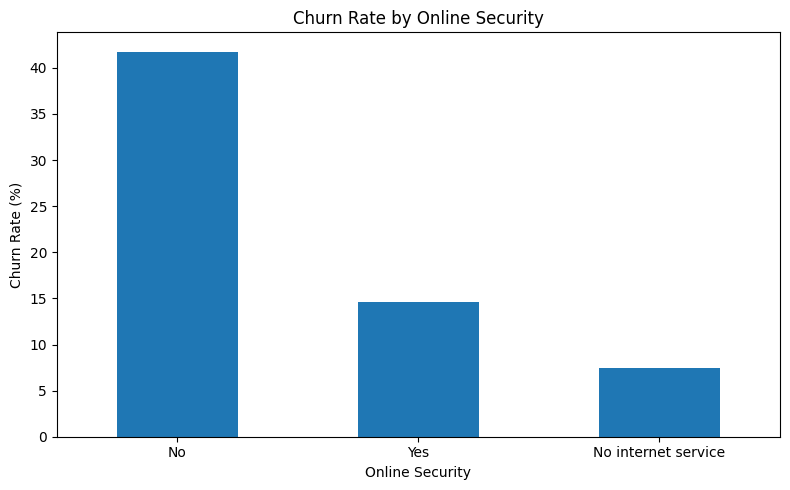

In [21]:
# Visualize churn rate by online security

security_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 🔎 Churn by Tenure and Contract Type

Looking at tenure and contract type together provides a more detailed view of customer churn patterns.

This helps identify whether the relationship between tenure and churn differs across contract types.

In [22]:
# Churn rate by tenure group and contract type

tenure_contract_churn = (
    df.groupby(["Tenure Group", "Contract"], observed=True)["ChurnFlag"]
    .mean()
    .mul(100)
    .unstack()
)

display(tenure_contract_churn)

Contract,Month-to-month,One year,Two year
Tenure Group,,,
0-12 months,51.354062,10.483871,0.000000
13-24 months,37.720488,8.121827,0.000000
25-48 months,32.917706,10.617761,2.189781
49-72 months,26.023392,12.933754,3.325416


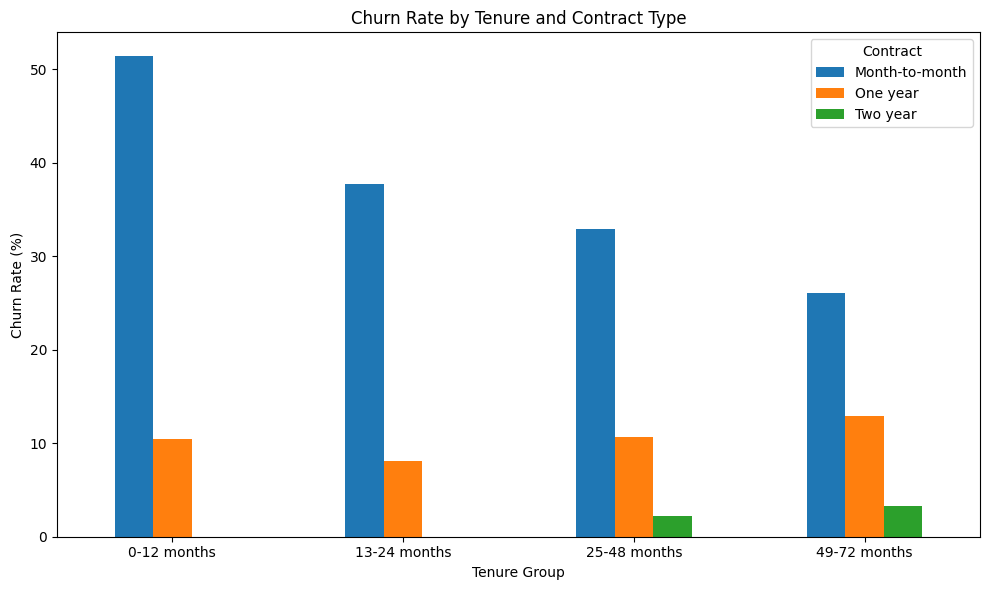

In [23]:
# Visualize tenure and contract churn

tenure_contract_churn.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Churn Rate by Tenure and Contract Type")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Contract")
plt.tight_layout()
plt.show()

## 👥 Churn by Customer Segments

Customer characteristics such as senior-citizen status, partner status, and dependent status can reveal differences in observed churn.

These segments can help identify groups that may require closer retention analysis.

In [24]:
# Churn rate by customer segment

segment_churn = pd.DataFrame({
    "Senior Citizen": df.groupby("SeniorCitizen")["ChurnFlag"].mean() * 100,
    "Partner": df.groupby("Partner")["ChurnFlag"].mean() * 100,
    "Dependents": df.groupby("Dependents")["ChurnFlag"].mean() * 100
})

display(segment_churn)

,Senior Citizen,Partner,Dependents
No,23.606168,32.957979,31.279140
Yes,41.681261,19.664903,15.450237


## 👨‍👩‍👧 Churn by Partner and Dependents

Combining partner and dependent status provides a more detailed view of customer segments.

This analysis helps identify whether customers with different household characteristics show different observed churn rates.

In [25]:
# Churn rate by partner and dependents

partner_dependents_churn = (
    df.groupby(["Partner", "Dependents"])["ChurnFlag"]
    .mean()
    .mul(100)
    .unstack()
)

display(partner_dependents_churn)

Dependents,No,Yes
Partner,,
No,34.237805,21.329640
Yes,25.408348,14.236707


## 💰 Average Monthly Charges by Churn Status

Comparing average monthly charges between churned and retained customers helps identify whether higher monthly billing is associated with observed churn.

In [26]:
# Average monthly charges by churn status

avg_charges_churn = (
    df.groupby("Churn")["MonthlyCharges"]
    .agg(["mean", "median"])
    .round(2)
)

display(avg_charges_churn)

,mean,median
Churn,,
No,61.27,64.43
Yes,74.44,79.65


## 📌 Key Findings Summary

The analysis reveals several important patterns in customer churn:

- Month-to-month customers have substantially higher observed churn than customers on longer-term contracts.
- Customers with shorter tenure show higher observed churn than long-tenured customers.
- Electronic check users have a higher observed churn rate than customers using other payment methods.
- Fiber optic customers show higher observed churn than DSL and customers without internet service.
- Customers without technical support or online security show higher observed churn.
- Higher monthly charge segments show higher observed churn.
- Senior citizens, customers without partners, and customers without dependents show higher observed churn in this dataset.

These findings represent **observed associations in the dataset and should not be interpreted as causal relationships.**

In [27]:
# Key churn metrics for summary

key_metrics = pd.DataFrame({
    "Metric": [
        "Overall Churn Rate",
        "Month-to-Month Churn Rate",
        "0-12 Month Tenure Churn Rate",
        "Electronic Check Churn Rate",
        "Fiber Optic Churn Rate"
    ],
    "Value": [
        f"{df['ChurnFlag'].mean() * 100:.2f}%",
        f"{contract_churn['Month-to-month']:.2f}%",
        f"{tenure_churn['0-12 months']:.2f}%",
        f"{payment_churn['Electronic check']:.2f}%",
        f"{internet_churn['Fiber optic']:.2f}%"
    ]
})

display(key_metrics)

,Metric,Value
0,Overall Churn Rate,26.54%
1,Month-to-Month Churn Rate,42.71%
2,0-12 Month Tenure Churn Rate,47.44%
3,Electronic Check Churn Rate,45.29%
4,Fiber Optic Churn Rate,41.89%


## 💡 Business Recommendations

Based on the observed churn patterns, the following areas could be considered for customer retention strategies:

1. **Focus on early-tenure customers**  
   Customers in their first 12 months show substantially higher observed churn. Early onboarding and engagement programs could be evaluated for this segment.

2. **Monitor month-to-month customers**  
   Month-to-month customers have a much higher observed churn rate than customers with longer contracts. Retention offers or contract-conversion strategies could be evaluated.

3. **Review high-charge customer segments**  
   Customers with higher monthly charges show higher observed churn. Pricing, service bundles, and perceived value could be examined for these customers.

4. **Investigate electronic-check customers**  
   Electronic-check users show a higher observed churn rate than other payment groups. Further analysis could determine whether payment experience or customer characteristics contribute to this pattern.

5. **Evaluate service adoption**  
   Customers without technical support or online security show higher observed churn. The relationship between service adoption and retention could be explored further.

6. **Use customer segmentation for retention analysis**  
   Tenure, contract type, internet service, payment method, and household characteristics can be combined to identify customer groups with different levels of observed churn risk.

> **Important:** These recommendations are based on observed patterns and should be validated through additional customer-level analysis, experimentation, and business context before implementation.

## 🏁 Conclusion

This project analyzed customer churn using Python and Pandas, supported by SQL-based business analysis and Power BI visualization.

The analysis identified several customer characteristics associated with higher observed churn, including shorter tenure, month-to-month contracts, electronic-check payments, fiber optic internet service, higher monthly charges, and limited adoption of support services.

The project demonstrates an end-to-end data analytics workflow:

**Raw Data → Data Cleaning → Exploratory Analysis → SQL Analysis → Visualization → Business Insights → Retention Recommendations**

The findings can be used as a starting point for deeper customer segmentation, churn-risk modeling, and retention strategy analysis.

In [28]:
print("Customer Churn & Retention Analysis")
print("=" * 45)
print(f"Total Customers: {len(df):,}")
print(f"Churned Customers: {df['ChurnFlag'].sum():,}")
print(f"Overall Churn Rate: {df['ChurnFlag'].mean() * 100:.2f}%")
print(f"Average Monthly Charges: ${df['MonthlyCharges'].mean():.2f}")
print(f"Average Tenure: {df['tenure'].mean():.2f} months")

Customer Churn & Retention Analysis
Total Customers: 7,043
Churned Customers: 1,869
Overall Churn Rate: 26.54%
Average Monthly Charges: $64.76
Average Tenure: 32.37 months
